In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer


In [3]:
(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(num_words=10000)


In [4]:
word_index = imdb.get_word_index()
index_word = {v+3: k for k, v in word_index.items()}
index_word[0] = "<PAD>"
index_word[1] = "<START>"
index_word[2] = "<UNK>"

def decode_review(text):
    return " ".join([index_word.get(i, "?") for i in text])

X_train_text = [decode_review(x) for x in X_train_raw]
X_test_text = [decode_review(x) for x in X_test_raw]


In [5]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)


In [6]:
model = LogisticRegression(
    max_iter=1000,
    solver="liblinear"
)

model.fit(X_train_tfidf, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [7]:
y_pred = model.predict(X_test_tfidf)


In [8]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy * 100, "%")


Model Accuracy: 87.976 %


In [9]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.88      0.87      0.88     12500
           1       0.88      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



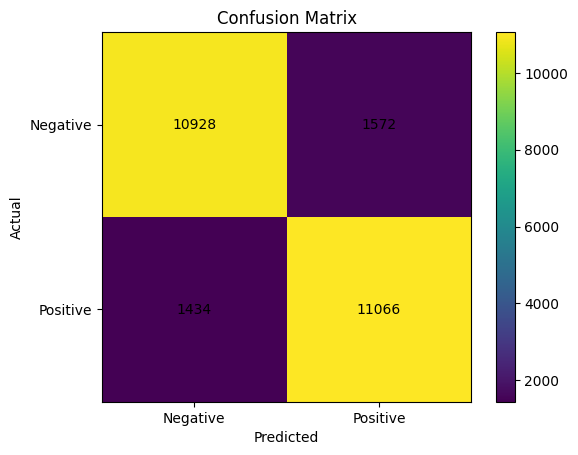

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.colorbar()
plt.xticks([0,1], ["Negative", "Positive"])
plt.yticks([0,1], ["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [11]:
def predict_custom_review(review_text):
    # clean text (same preprocessing)
    review_text = review_text.lower()
    review_text = re.sub(r"[^a-z\s]", "", review_text)

    # TF-IDF transform
    vector = tfidf.transform([review_text])

    # prediction
    prediction = model.predict(vector)[0]

    if prediction == 1:
        return "Positive Review 😊"
    else:
        return "Negative Review 😞"


In [12]:
print(predict_custom_review("This movie was absolutely amazing and inspiring"))
print(predict_custom_review("Worst movie ever, complete waste of time"))
print(predict_custom_review("The acting was good but the story was boring"))
print(predict_custom_review("I loved this film, great direction and music"))


Positive Review 😊
Negative Review 😞
Negative Review 😞
Positive Review 😊
